In [1]:
import importlib.util
import subprocess
import sys

# Kaggle already provides TensorFlow; only install if a package is missing.
required_packages = ['numpy', 'matplotlib', 'scikit-learn', 'opencv-python', 'tqdm', 'requests']

for package in required_packages:
    module_name = package.replace('-', '_')
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])

print('✓ Base packages checked successfully')

✓ Base packages checked successfully


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import pickle
import requests
import zipfile
from tqdm import tqdm

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow version: {tf.__version__}')
print(f'GPU Available: {gpus if gpus else "None"}')
print(f'Running on: {"GPU" if gpus else "CPU"}')

2026-04-09 01:33:17.608779: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775698397.775201      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775698397.825149      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775698398.213477      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775698398.213514      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775698398.213517      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Running on: GPU


## 3. Configuration

In [3]:
CONFIG = {
    'INPUT_SIZE': 64,              # Input image size (64x64)
    'BATCH_SIZE': 64,              # Batch size for training
    'EPOCHS': 355,                 # Total epochs (as per paper)
    'LEARNING_RATE': 0.001,        # Adam optimizer learning rate
    'LATENT_DIM': 128,             # Latent dimension size
    'VALIDATION_SPLIT': 0.2,       # 20% validation split
    'RANDOM_SEED': 42
}

# Set random seeds for reproducibility
np.random.seed(CONFIG['RANDOM_SEED'])
tf.random.set_seed(CONFIG['RANDOM_SEED'])

# Kaggle-safe output paths
BASE_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('.')
MODEL_DIR = BASE_DIR / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = BASE_DIR / 'data' / 'cae_training'
DATA_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / 'cae_best.keras'
WEIGHTS_PATH = MODEL_DIR / 'cae_best.weights.h5'
HISTORY_PATH = MODEL_DIR / 'cae_training_history.pkl'

print(f'Model directory: {MODEL_DIR}')
print(f'Data directory: {DATA_DIR}')
print(f'Configuration: {CONFIG}')
print(f'Using base directory: {BASE_DIR}')

Model directory: /kaggle/working/models
Data directory: /kaggle/working/data/cae_training
Configuration: {'INPUT_SIZE': 64, 'BATCH_SIZE': 64, 'EPOCHS': 355, 'LEARNING_RATE': 0.001, 'LATENT_DIM': 128, 'VALIDATION_SPLIT': 0.2, 'RANDOM_SEED': 42}
Using base directory: /kaggle/working


In [4]:
def download_tiny_imagenet(data_dir, dataset_type='train'):
    data_dir = Path(data_dir)
    train_dir = data_dir / 'tiny-imagenet-200' / 'train'
    
    if train_dir.exists():
        print(f"✓ Dataset already exists at {train_dir}")
        return train_dir
    
    print("Downloading Tiny ImageNet dataset (200MB)...")
    url = 'http://cs231n.stanford.edu/tiny-imagenet-200.zip'
    zip_path = data_dir / 'tiny-imagenet-200.zip'
    
    # Download with progress bar
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))
    
    with open(zip_path, 'wb') as f:
        with tqdm(total=total_size, unit='B', unit_scale=True) as pbar:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
                pbar.update(len(chunk))
    
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)
    
    zip_path.unlink()  # Remove zip file
    print(f"✓ Dataset extracted to {data_dir}")
    
    return train_dir

# Download dataset
train_dir = download_tiny_imagenet(DATA_DIR)

100%|██████████| 248M/248M [00:38<00:00, 6.36MB/s]   


Extracting dataset...
✓ Dataset extracted to /kaggle/working/data/cae_training


## 5. Load and Preprocess Dataset

In [5]:
def load_images(directory, image_size=64, max_images=None, sample_subset=True):
    images = []
    directory = Path(directory)
    
    # Get all image directories
    img_dirs = list(directory.glob('**/images'))[:50] if sample_subset else list(directory.glob('**/images'))
    print(f"Processing {len(img_dirs)} image directories...")
    
    image_count = 0
    failed_count = 0
    
    for img_dir in tqdm(img_dirs, desc="Loading images"):
        if max_images and image_count >= max_images:
            break
            
        for img_path in img_dir.glob('*.JPEG'):
            if max_images and image_count >= max_images:
                break
            
            try:
                # Load image
                img = cv2.imread(str(img_path))
                if img is None:
                    failed_count += 1
                    continue
                
                # Convert BGR to RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                # Resize to target size
                img = cv2.resize(img, (image_size, image_size))
                
                # Normalize to [0, 1]
                img = img.astype('float32') / 255.0
                
                images.append(img)
                image_count += 1
                
            except Exception:
                failed_count += 1
                continue
    
    images_array = np.array(images)
    print(f"✓ Loaded {image_count} images (Failed: {failed_count})")
    print(f"Dataset shape: {images_array.shape}")
    print(f"Value range: [{images_array.min():.4f}, {images_array.max():.4f}]")
    
    return images_array

# Load dataset (sampling subset for faster training)
X_train = load_images(train_dir, image_size=CONFIG['INPUT_SIZE'], max_images=25000, sample_subset=True)

Processing 50 image directories...


Loading images: 100%|██████████| 50/50 [00:03<00:00, 13.77it/s]


✓ Loaded 25000 images (Failed: 0)
Dataset shape: (25000, 64, 64, 3)
Value range: [0.0000, 1.0000]


## 6. Split Data into Train/Validation

In [6]:
X_train, X_val = train_test_split(
    X_train, 
    test_size=CONFIG['VALIDATION_SPLIT'],
    random_state=CONFIG['RANDOM_SEED']
)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Memory usage: {(X_train.nbytes + X_val.nbytes) / (1024**3):.2f} GB")

Training set shape: (20000, 64, 64, 3)
Validation set shape: (5000, 64, 64, 3)
Memory usage: 1.14 GB


## 7. Build Convolutional Autoencoder Architecture

In [7]:
def build_cae_model(input_size=64, latent_dim=128):

    
    # Input
    inputs = keras.Input(shape=(input_size, input_size, 3))
    
    # ================== ENCODER ==================
    # Conv Block 1: 64 filters, max pooling
    x = layers.Conv2D(32, kernel_size=3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D(pool_size=2)(x)  # 64x64 -> 32x32
    
    # Conv Block 2: 128 filters, max pooling
    x = layers.Conv2D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(pool_size=2)(x)  # 32x32 -> 16x16
    
    # Conv Block 3: 256 filters, NO max pooling (as per paper)
    x = layers.Conv2D(128, kernel_size=3, padding='same', activation='relu')(x)
    # No max pooling on 3rd layer
    
    # Bottleneck: flatten and dense for latent representation
    x = layers.Flatten()(x)
    x = layers.Dense(latent_dim, activation='relu', name='latent')(x)
    
    # ================== DECODER ==================
    # Reshape from latent dim back to spatial dims
    x = layers.Dense(16 * 16 * 128, activation='relu')(x)
    x = layers.Reshape((16, 16, 128))(x)
    
    # Upsampling Block 1: upsample 16x16 -> 32x32
    x = layers.UpSampling2D(size=2)(x)
    x = layers.Conv2D(64, kernel_size=3, padding='same', activation='relu')(x)
    
    # Upsampling Block 2: upsample 32x32 -> 64x64
    x = layers.UpSampling2D(size=2)(x)
    x = layers.Conv2D(32, kernel_size=3, padding='same', activation='relu')(x)
    
    # Output layer: reconstruct to original RGB image
    outputs = layers.Conv2D(3, kernel_size=3, padding='same', activation='sigmoid')(x)
    
    # Create model
    autoencoder = Model(inputs, outputs, name='ConvolutionalAutoencoder')
    
    return autoencoder

# Build model
model = build_cae_model(
    input_size=CONFIG['INPUT_SIZE'],
    latent_dim=CONFIG['LATENT_DIM']
)

# Print model summary
model.summary()

I0000 00:00:1775698479.223513      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775698479.229215      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "ConvolutionalAutoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32768)          │     4,227,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,607,875 (32.84 MB)

 Trainable params: 8,607,875 (32.84 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Compile Model

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CONFIG['LEARNING_RATE']),
    loss='mse',  
    metrics=['mse', 'mae']
)

print("✓ Model compiled successfully")
print(f"Optimizer: Adam (lr={CONFIG['LEARNING_RATE']})")
print(f"Loss: MSE")

✓ Model compiled successfully
Optimizer: Adam (lr=0.001)
Loss: MSE


## 9. Define Training Callbacks

In [9]:
callbacks = [
    ModelCheckpoint(
        str(MODEL_PATH),
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1,
        save_freq='epoch'
    ),
    
    # Save weights only
    ModelCheckpoint(
        str(WEIGHTS_PATH.with_name(f"{WEIGHTS_PATH.stem}.weights.h5")),
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=0,
        save_weights_only=True
    ),
    
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-7,
        verbose=1
    )
]


## 10. Train the Model

In [10]:
history = model.fit(
    X_train, X_train, 
    batch_size=CONFIG['BATCH_SIZE'],
    epochs=CONFIG['EPOCHS'],
    validation_data=(X_val, X_val),
    callbacks=callbacks,
    verbose=1
)



Epoch 1/355


I0000 00:00:1775698487.482221     141 service.cc:152] XLA service 0x7ac59c006ea0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775698487.482259     141 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775698487.482263     141 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775698488.013989     141 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-09 01:34:50.122604: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-09 01:34:50.273195: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  5/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.0808 - mae: 0.2421 - mse: 0.0808

I0000 00:00:1775698494.129476     141 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0580 - mae: 0.1940 - mse: 0.0580

2026-04-09 01:35:04.619286: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-09 01:35:04.764716: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0579 - mae: 0.1938 - mse: 0.0579
Epoch 1: val_loss improved from inf to 0.03125, saving model to /kaggle/working/models/cae_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - loss: 0.0578 - mae: 0.1937 - mse: 0.0578 - val_loss: 0.0312 - val_mae: 0.1330 - val_mse: 0.0312 - learning_rate: 0.0010
Epoch 2/355
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0304 - mae: 0.1306 - mse: 0.0304
Epoch 2: val_loss improved from 0.03125 to 0.03025, saving model to /kaggle/working/models/cae_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 0.0304 - mae: 0.1306 - mse: 0.0304 - val_loss: 0.0303 - val_mae: 0.1296 - val_mse: 0.0303 - learning_rate: 0.0010
Epoch 3/355
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0292 - mae: 0.1271 - mse: 0.0292
Epoch 3: val_loss improved from 0.03025 to 0.02951, saving model to /kaggle/working/models/cae_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 0.0292 - mae: 0.1271 - mse

## 11. Save Training History

In [11]:
with open(HISTORY_PATH, 'wb') as f:
    pickle.dump(history.history, f)

print(f"✓ Training history saved to {HISTORY_PATH}")

✓ Training history saved to /kaggle/working/models/cae_training_history.pkl


## 12. Plot Training History

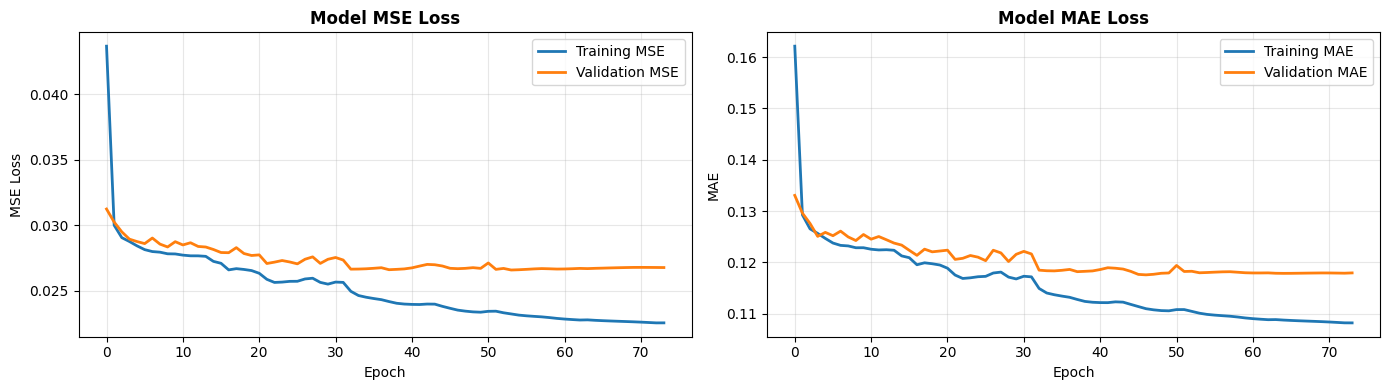

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Training MSE', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation MSE', linewidth=2)
axes[0].set_title('Model MSE Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_title('Model MAE Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'training_history.png', dpi=150)
plt.show()



## 13. Test Model on Sample Images

In [13]:
best_model = keras.models.load_model(str(MODEL_PATH))

X_val_pred = best_model.predict(X_val[:10])

reconstruction_errors = np.mean(np.square(X_val[:10] - X_val_pred), axis=(1, 2, 3))

print("\nReconstruction Error Statistics:")
print(f"Mean Error: {reconstruction_errors.mean():.6f}")
print(f"Std Dev: {reconstruction_errors.std():.6f}")
print(f"Min Error: {reconstruction_errors.min():.6f}")
print(f"Max Error: {reconstruction_errors.max():.6f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Reconstruction Error Statistics:
Mean Error: 0.022773
Std Dev: 0.008711
Min Error: 0.013718
Max Error: 0.043736


## 14. Visualize Reconstructions

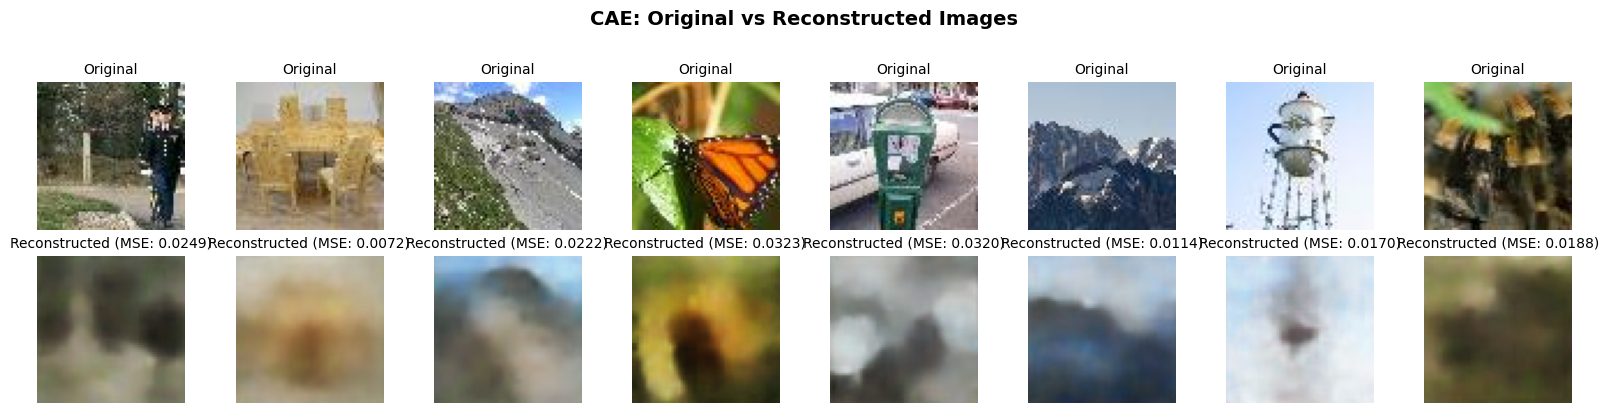

✓ Reconstruction samples saved to /kaggle/working/models/reconstruction_samples.png


In [14]:
n_samples = 8
sample_indices = np.random.choice(len(X_val), n_samples, replace=False)

fig, axes = plt.subplots(2, n_samples, figsize=(16, 4))

for i, idx in enumerate(sample_indices):
    # Original
    axes[0, i].imshow(X_val[idx])
    axes[0, i].set_title('Original', fontsize=10)
    axes[0, i].axis('off')
    
    # Reconstructed
    reconstructed = best_model.predict(X_val[idx:idx+1], verbose=0)[0]
    axes[1, i].imshow(reconstructed)
    error = np.mean(np.square(X_val[idx] - reconstructed))
    axes[1, i].set_title(f'Reconstructed (MSE: {error:.4f})', fontsize=10)
    axes[1, i].axis('off')

plt.suptitle('CAE: Original vs Reconstructed Images', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'reconstruction_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Reconstruction samples saved to {MODEL_DIR / 'reconstruction_samples.png'}")

## 15. Extract and Save Encoder Model (for Team Assignment)

In [15]:
encoder_model = keras.Model(
    inputs=best_model.input,
    outputs=best_model.get_layer('latent').output,
    name='CAE_Encoder'
)

encoder_path = MODEL_DIR / 'cae_encoder.h5'
encoder_model.save(str(encoder_path))

print(f"✓ Encoder model saved to {encoder_path}")
print(f"\nEncoder Output Shape: {encoder_model.output.shape}")
print(f"Encoder will extract {CONFIG['LATENT_DIM']}-dimensional feature vectors")

✓ Encoder model saved to /kaggle/working/models/cae_encoder.h5

Encoder Output Shape: (None, 128)
Encoder will extract 128-dimensional feature vectors


## 16. Model Summary and Results

In [16]:
val_loss, val_mse, val_mae = best_model.evaluate(X_val, X_val, verbose=0)

print("\n" + "="*60)
print("CONVOLUTIONAL AUTOENCODER TRAINING SUMMARY")
print("="*60)
print(f"\nModel Architecture:")
print(f"  - Input Size: {CONFIG['INPUT_SIZE']}x{CONFIG['INPUT_SIZE']}x3")
print(f"  - Latent Dimension: {CONFIG['LATENT_DIM']}")
print(f"  - Total Parameters: {best_model.count_params():,}")
print(f"\nTraining Configuration:")
print(f"  - Batch Size: {CONFIG['BATCH_SIZE']}")
print(f"  - Epochs: {len(history.history['loss'])}")
print(f"  - Optimizer: Adam (lr={CONFIG['LEARNING_RATE']})")
print(f"  - Loss Function: MSE")
print(f"\nData:")
print(f"  - Training Samples: {X_train.shape[0]:,}")
print(f"  - Validation Samples: {X_val.shape[0]:,}")
print(f"\nFinal Validation Metrics:")
print(f"  - MSE Loss: {val_mse:.6f}")
print(f"  - MAE Loss: {val_mae:.6f}")
print(f"\nSaved Models:")
print(f"  - Full Model: {MODEL_PATH}")
print(f"  - Weights Only: {WEIGHTS_PATH}")
print(f"  - Encoder: {encoder_path}")
print(f"\nTraining History:")
print(f"  - History File: {HISTORY_PATH}")
print(f"\nVisualizations:")
print(f"  - Training Curves: {MODEL_DIR / 'training_history.png'}")
print(f"  - Reconstructions: {MODEL_DIR / 'reconstruction_samples.png'}")
print("="*60)
print("\n✓ Training complete! Ready for integration with Team Assignment module.")


CONVOLUTIONAL AUTOENCODER TRAINING SUMMARY

Model Architecture:
  - Input Size: 64x64x3
  - Latent Dimension: 128
  - Total Parameters: 8,607,875

Training Configuration:
  - Batch Size: 64
  - Epochs: 74
  - Optimizer: Adam (lr=0.001)
  - Loss Function: MSE

Data:
  - Training Samples: 20,000
  - Validation Samples: 5,000

Final Validation Metrics:
  - MSE Loss: 0.026596
  - MAE Loss: 0.117981

Saved Models:
  - Full Model: /kaggle/working/models/cae_best.keras
  - Weights Only: /kaggle/working/models/cae_best.weights.h5
  - Encoder: /kaggle/working/models/cae_encoder.h5

Training History:
  - History File: /kaggle/working/models/cae_training_history.pkl

Visualizations:
  - Training Curves: /kaggle/working/models/training_history.png
  - Reconstructions: /kaggle/working/models/reconstruction_samples.png

✓ Training complete! Ready for integration with Team Assignment module.


## 17. Example: Extract Features from Player Crops

In [17]:

def extract_player_features(player_crops, encoder_model_path=None):
    """
    Extract feature vectors from player crop images using the trained CAE encoder.
    
    Parameters:
    -----------
    player_crops : np.ndarray
        Array of shape (N, 64, 64, 3) with player crops normalized to [0, 1]
    encoder_model_path : str, optional
        Path to encoder model. If None, uses the model from this session.
    
    Returns:
    --------
    np.ndarray : Feature vectors of shape (N, LATENT_DIM)
    """
    if encoder_model_path:
        encoder = keras.models.load_model(encoder_model_path)
    else:
        encoder = encoder_model  # Use current session's encoder
    
    features = encoder.predict(player_crops, verbose=0)
    return features

# Example usage
print("Example: Extracting features from sample player crops")
sample_crops = X_val[:10]  # Take 10 validation samples as example
features = extract_player_features(sample_crops, encoder_model_path=None)

print(f"\nInput crops shape: {sample_crops.shape}")
print(f"Extracted features shape: {features.shape}")
print(f"Feature vector range: [{features.min():.4f}, {features.max():.4f}]")
print(f"\nThese {CONFIG['LATENT_DIM']}-dimensional features can now be used with K-means clustering")
print(f"for team assignment as described in the paper.")

Example: Extracting features from sample player crops

Input crops shape: (10, 64, 64, 3)
Extracted features shape: (10, 128)
Feature vector range: [0.0000, 6.6411]

These 128-dimensional features can now be used with K-means clustering
for team assignment as described in the paper.


## Notes for Integration

To use this CAE model in your team assignment pipeline:

1. **Load the encoder model:**
   ```python
   from tensorflow import keras
   encoder = keras.models.load_model('models/cae_encoder.h5')
   ```

2. **Extract features from player crops:**
   ```python
   player_crop = cv2.resize(player_bbox_image, (64, 64)) / 255.0
   feature_vector = encoder.predict(player_crop[np.newaxis, ...])
   ```

3. **Use with K-means clustering:**
   - Collect 100 random frames from video
   - Extract all player crops (64×64)
   - Get feature vectors using encoder
   - Apply K-means with k=3 (Team1, Team2, Other)
   - Assign players based on nearest cluster center

4. **Expected performance:**
   - ~92% accuracy on team assignment
   - Generalizable across different football videos
   - No fine-tuning required